In [13]:
#CNN with numpy no pytroch ...

import numpy as np
import matplotlib.pyplot as plt

print("numpy version:", np.__version__)


numpy version: 2.0.2


In [2]:


def conv2d_single_filter(image, kernel):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            patch = image[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(patch * kernel)

    return output

test_image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 1],
    [1, 0, 1, 3, 2],
    [0, 1, 2, 4, 1]
], dtype=float)

edge_kernel = np.array([
    [1,  0, -1],
    [1,  0, -1],
    [1,  0, -1]
], dtype=float)

result = conv2d_single_filter(test_image, edge_kernel)
print("Input image shape:", test_image.shape)
print("Kernel shape:", edge_kernel.shape)
print("Output feature map shape:", result.shape)
print("\nOutput feature map:")
print(result)

Input image shape: (5, 5)
Kernel shape: (3, 3)
Output feature map shape: (3, 3)

Output feature map:
[[-6. 12. 16.]
 [-4.  7. 13.]
 [-4.  0.  8.]]


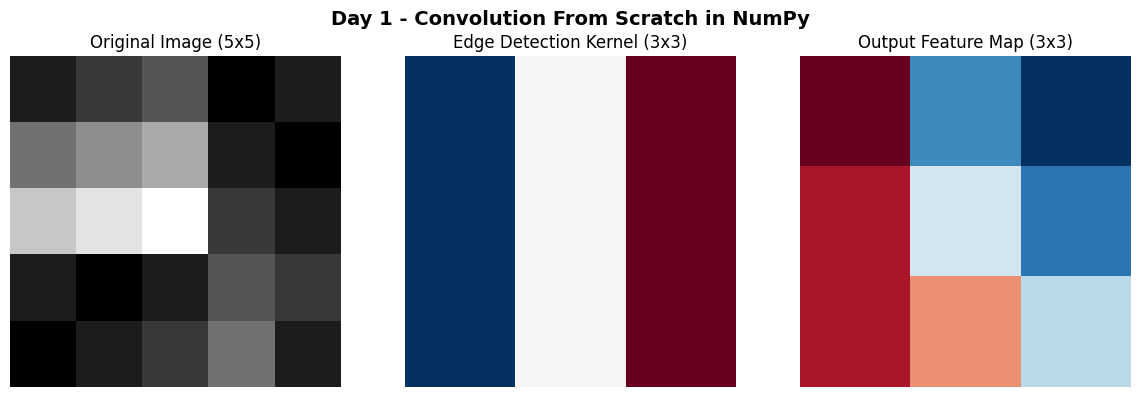

In [5]:


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# original image
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original Image (5x5)')
axes[0].axis('off')

# the kernel we used
axes[1].imshow(edge_kernel, cmap='RdBu')
axes[1].set_title('Edge Detection Kernel (3x3)')
axes[1].axis('off')

# the output feature map
axes[2].imshow(result, cmap='RdBu')
axes[2].set_title('Output Feature Map (3x3)')
axes[2].axis('off')

plt.suptitle('Day 1 - Convolution From Scratch in NumPy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('day1_convolution.png', dpi=150, bbox_inches='tight')
plt.show()



Before ReLU:
[[-6. 12. 16.]
 [-4.  7. 13.]
 [-4.  0.  8.]]

After ReLU:
[[ 0. 12. 16.]
 [ 0.  7. 13.]
 [ 0.  0.  8.]]

Notice all negative values became 0!


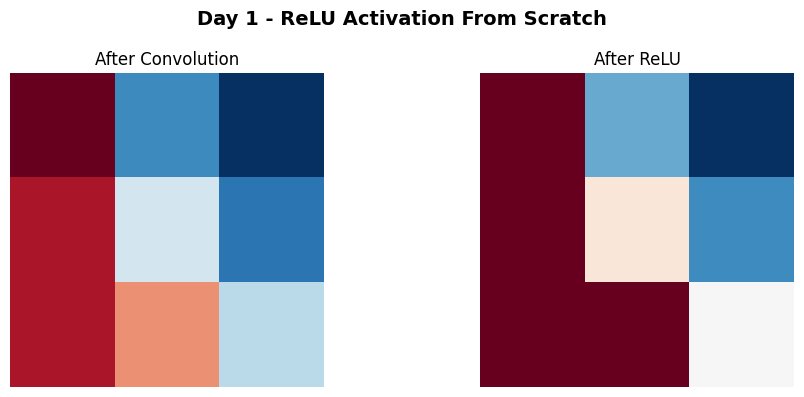

In [14]:


def relu(x):
    # any negative value becomes 0
    # positive values stay as they are
    return np.maximum(0, x)

# applying relu to our convolution output
relu_output = relu(result)

print("Before ReLU:")
print(result)
print("\nAfter ReLU:")
print(relu_output)
print("\nNotice all negative values became 0!")

# visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(result, cmap='RdBu')
axes[0].set_title('After Convolution')
axes[0].axis('off')

axes[1].imshow(relu_output, cmap='RdBu')
axes[1].set_title('After ReLU')
axes[1].axis('off')

plt.suptitle('Day 1 - ReLU Activation From Scratch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('day1_relu.png', dpi=150, bbox_inches='tight')
plt.show()



In [15]:


def maxpool2d(feature_map, pool_size=2, stride=2):
    h, w = feature_map.shape

    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            # take maximum value in each pool window
            patch = feature_map[
                i*stride:i*stride+pool_size,
                j*stride:j*stride+pool_size
            ]
            output[i, j] = np.max(patch)

    return output

pool_output = maxpool2d(relu_output, pool_size=2, stride=1)

print("After ReLU shape:", relu_output.shape)
print("After MaxPool shape:", pool_output.shape)
print("\nAfter ReLU:")
print(relu_output)
print("\nAfter MaxPool:")
print(pool_output)


After ReLU shape: (3, 3)
After MaxPool shape: (2, 2)

After ReLU:
[[ 0. 12. 16.]
 [ 0.  7. 13.]
 [ 0.  0.  8.]]

After MaxPool:
[[12. 16.]
 [ 7. 13.]]


COMPLETE CNN FORWARD PASS FROM SCRATCH
Step 1 - After Convolution: (3, 3)
Step 2 - After ReLU: (3, 3)
Step 3 - After MaxPool: (2, 2)

Final output:
[[12. 16.]
 [ 7. 13.]]


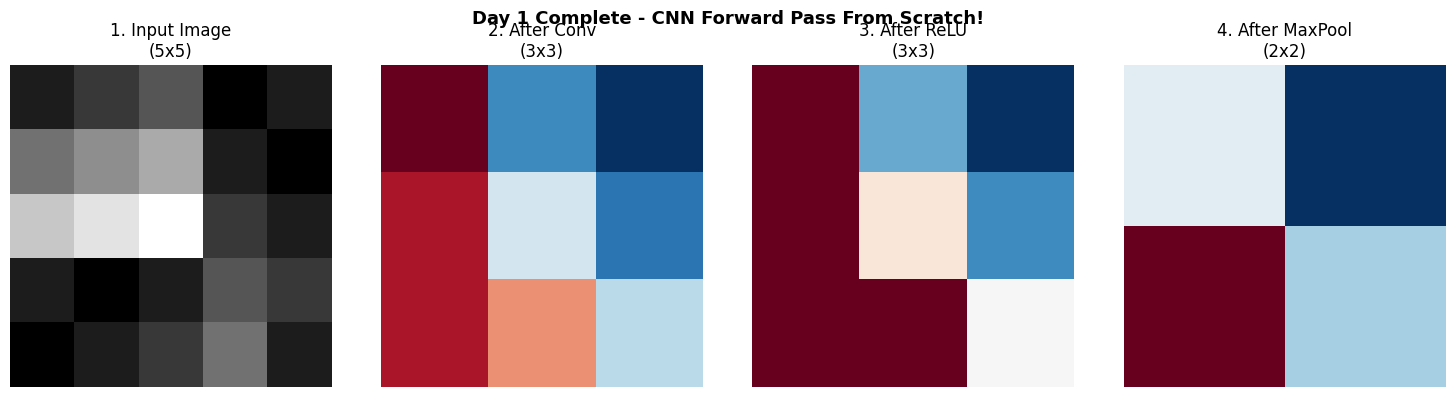

In [12]:


def cnn_forward_pass(image, kernel, pool_size=2, stride=1):

    # step 1 - convolution
    conv_out = conv2d_single_filter(image, kernel)
    print("Step 1 - After Convolution:", conv_out.shape)

    # step 2 - relu activation
    relu_out = relu(conv_out)
    print("Step 2 - After ReLU:", relu_out.shape)

    # step 3 - max pooling
    pool_out = maxpool2d(relu_out, pool_size, stride)
    print("Step 3 - After MaxPool:", pool_out.shape)

    return conv_out, relu_out, pool_out

print("COMPLETE CNN FORWARD PASS FROM SCRATCH")

conv, relu_map, pool = cnn_forward_pass(test_image, edge_kernel)

print("\nFinal output:")
print(pool)


# final visualization
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('1. Input Image\n(5x5)')
axes[0].axis('off')

axes[1].imshow(conv, cmap='RdBu')
axes[1].set_title('2. After Conv\n(3x3)')
axes[1].axis('off')

axes[2].imshow(relu_map, cmap='RdBu')
axes[2].set_title('3. After ReLU\n(3x3)')
axes[2].axis('off')

axes[3].imshow(pool, cmap='RdBu')
axes[3].set_title('4. After MaxPool\n(2x2)')
axes[3].axis('off')

plt.suptitle('Day 1 Complete - CNN Forward Pass From Scratch!',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day1_complete_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

